In [1]:
import torch
import torch.nn as n
import torch.nn.functional as f

class model(n.Module):
    def __init__(self, in_features=3, h1=8,h2=8,out=11):
        super().__init__()
        self.fc1=n.Linear(in_features,h1)
        self.fc2=n.Linear(h1,h2)
        self.out=n.Linear(h2,out)

    def forward(self,x):
        x=f.relu(self.fc1(x))
        x=f.relu(self.fc2(x))
        x=self.out(x)
        return x

torch.manual_seed(13)
model=model()


In [2]:
from google.colab import files
uploaded = files.upload()

Saving sorted_encoded_colors_cleaned copy.xlsx to sorted_encoded_colors_cleaned copy.xlsx


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("sorted_encoded_colors_cleaned copy.xlsx")
print(df.tail())

my_df = df.copy()

my_df["label_id"] = my_df["label_id"].replace("black", 0)
my_df ["label_id"] = my_df["label_id"]. replace("blue", 1)
my_df ["label_id"] = my_df["label_id"]. replace("brown",2)
my_df ["label_id"] = my_df["label_id"]. replace("grey",3)
my_df ["label_id"] = my_df["label_id"]. replace("green",4)
my_df ["label_id"] = my_df["label_id"]. replace("orange",5)
my_df ["label_id"] = my_df["label_id"]. replace("pink",6)
my_df ["label_id"] = my_df["label_id"]. replace("purple",7)
my_df ["label_id"] = my_df["label_id"]. replace("red",8)
my_df ["label_id"] = my_df["label_id"]. replace("white",9)
my_df ["label_id"] = my_df["label_id"]. replace("yellow",10)
print(df.iloc[182:187])
print(type(df))



       r    g    b  label_id
364  255  249   23        10
365  255  250  134        10
366  255  253   55        10
367  255  253  120        10
368  255  255  129        10
       r    g    b  label_id
182  117  128    0         4
183  117  184   79         4
184  118  253  168         4
185  118  255  123         4
186  127  143   78         4
<class 'pandas.core.frame.DataFrame'>


In [4]:
df=my_df
x = my_df.drop("label_id", axis=1)
y = my_df["label_id"]


In [5]:
x = x.values
y = y.values
x


array([[  0,   0,   0],
       [  7,  13,  13],
       [ 27,  36,  49],
       ...,
       [255, 253,  55],
       [255, 253, 120],
       [255, 255, 129]])

In [6]:
from numpy import test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2 ,random_state= 19)

In [7]:
x_train = torch.FloatTensor(x_train)
x_test= torch.FloatTensor(x_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [8]:
saabadi = n.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(),lr = 0.01)

In [9]:
model.parameters

<bound method Module.parameters of model(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=11, bias=True)
)>

In [10]:
epochs = 5000
losses = []
for i in range(epochs):
  y_pred = model.forward(x_train)

  loss = saabadi(y_pred,y_train)
  losses.append (loss.detach().numpy())

  if i % 10 == 0:
    print(f'epoch: {i} and loss:  {loss.item()}')

  optimiser.zero_grad()
  loss.backward()
  optimiser.step()


epoch: 0 and loss:  27.630615234375
epoch: 10 and loss:  2.913191318511963
epoch: 20 and loss:  2.2943670749664307
epoch: 30 and loss:  2.2021069526672363
epoch: 40 and loss:  2.0674502849578857
epoch: 50 and loss:  1.9496468305587769
epoch: 60 and loss:  1.857985496520996
epoch: 70 and loss:  1.7676526308059692
epoch: 80 and loss:  1.6828902959823608
epoch: 90 and loss:  1.6519798040390015
epoch: 100 and loss:  1.6170814037322998
epoch: 110 and loss:  1.5767956972122192
epoch: 120 and loss:  1.550636649131775
epoch: 130 and loss:  1.524658203125
epoch: 140 and loss:  1.4844385385513306
epoch: 150 and loss:  1.4175294637680054
epoch: 160 and loss:  1.342750072479248
epoch: 170 and loss:  1.2673377990722656
epoch: 180 and loss:  1.2199569940567017
epoch: 190 and loss:  1.1729943752288818
epoch: 200 and loss:  1.1447069644927979
epoch: 210 and loss:  1.1224223375320435
epoch: 220 and loss:  1.1031638383865356
epoch: 230 and loss:  1.086786150932312
epoch: 240 and loss:  1.072565674781799

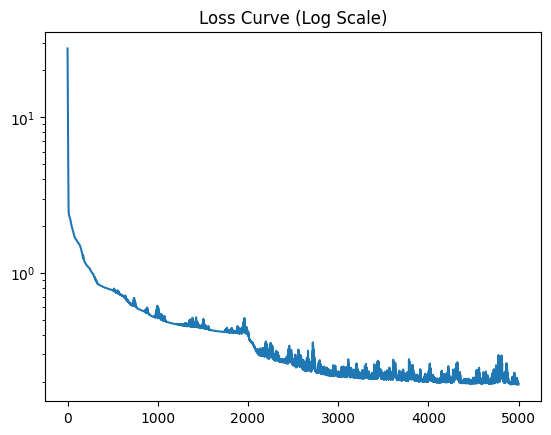

In [11]:
plt.plot(losses)
plt.yscale('log') # This helps see the detail when loss gets very small
plt.title('Loss Curve (Log Scale)')
plt.show()

In [12]:
with torch.no_grad ():
  y_eval = model.forward(x_test)
  loss = saabadi(y_eval,y_test)



In [ ]:
loss

tensor(1.4260)

In [13]:
correct = 0

with torch.no_grad():
  for i, data in enumerate(x_test):
    y_val = model.forward(data)

    # Assuming y_test[i] is the numeric label (0-10)
    if y_test[i] == 0:
        x = "Black"
    elif y_test[i] == 1:
        x = "Blue"
    elif y_test[i] == 2:
        x = "Brown"
    elif y_test[i] == 3:
        x = "Gray"
    elif y_test[i] == 4:
        x = "Green"
    elif y_test[i] == 5:
        x = "Orange"
    elif y_test[i] == 6:
        x = "Pink"
    elif y_test[i] == 7:
        x = "Purple"
    elif y_test[i] == 8:
        x = "Red"
    elif y_test[i] == 9:
        x = "White"
    else:
        x = "Yellow"

    print (f' (i+1).) {str(y_val)} \t (y_test{1}) \t {y_val. argmax (). item ( )}')

    if y_val. argmax().item() == y_test[i]:
      correct += 1
    print (f"we got {correct} correct!")


 (i+1).) tensor([ -58.9735,   43.2177,  -22.2317,   15.7564,   42.3841, -275.3376,
         -94.9702,   -7.7618,  -49.6971,   -9.5911,  -21.8347]) 	 (y_test1) 	 1
we got 0 correct!
 (i+1).) tensor([ -38.2014,   27.4427,  -11.5933,   13.0363,   24.5752, -178.2810,
         -55.7476,   -1.9959,  -30.3894,   -2.5362,  -17.9611]) 	 (y_test1) 	 1
we got 1 correct!
 (i+1).) tensor([ -15.4693, -134.4064,   21.7804,    8.8376,    4.8043,   11.1460,
          13.3200,    3.7072,   16.7416,   16.4316,   15.1986]) 	 (y_test1) 	 2
we got 2 correct!
 (i+1).) tensor([ -23.5435, -240.4925,   34.5118,    8.9464,   11.5081,   38.0032,
          18.3652,    0.9948,   29.4172,   22.4187,   36.1390]) 	 (y_test1) 	 5
we got 2 correct!
 (i+1).) tensor([ -59.5974, -115.2027,    1.3309,   14.4952,   42.6094, -186.8055,
         -67.4169,   -8.6021,  -21.7024,    2.5573,    9.8314]) 	 (y_test1) 	 4
we got 3 correct!
 (i+1).) tensor([-7.1253e+01, -1.2260e+02, -2.1960e+00,  1.5884e+01,  5.2571e+01,
        -2.31

In [16]:
import torch


colors = ["Black", "Blue", "Brown", "Gray", "Green", "Orange", "Pink", "Purple", "Red", "White", "Yellow"]

def predict_color():

    try:
        r = int(input("Enter Red (0-255): "))
        g = int(input("Enter Green (0-255): "))
        b = int(input("Enter Blue (0-255): "))

        input_rgb = torch.tensor([[r, g, b]], dtype=torch.float32)

        # Optional: Normalize if you did this during training
        # input_rgb = input_rgb / 255.0


        model.eval() # Set to evaluation mode
        with torch.no_grad():
            output = model(input_rgb)
            prediction = torch.argmax(output, dim=1).item()

        print(f"\n--- AI Result ---")
        print(f"The AI thinks this color is: {colors[prediction]}")

    except ValueError:
        print("Please enter valid numbers between 0 and 255.")


predict_color()

Enter Red (0-255): 149
Enter Green (0-255): 200
Enter Blue (0-255): 35

--- AI Result ---
The AI thinks this color is: Green
